# Gene Expression Simulation


In [1]:
import networkx as nx
import pycea as py
import scanpy as sc
import treedata as td

import cassiopeia as cas

## Tree simulation

First, we need to simulate a lineage tree which we can do with {func}`cassiopeia.sim.birth_death_process`

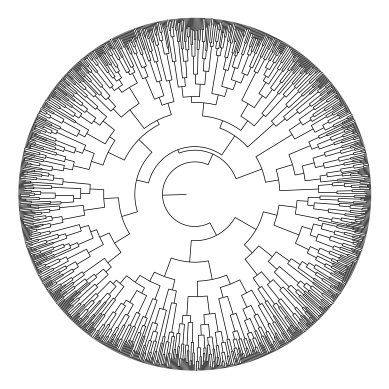

In [2]:
tdata = cas.sim.birth_death_process(num_extant=1000, alignment="nodes")
py.pl.tree(tdata, polar=True);

## Brownian motion simulation

In [3]:
brownian_tdata = cas.sim.brownian_expression(tdata, random_seed=42, momentum=0.8)

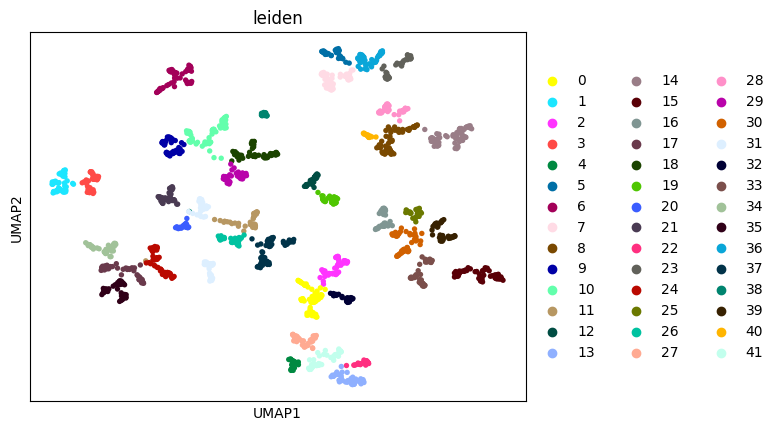

In [4]:
sc.pp.pca(brownian_tdata)
sc.pp.neighbors(brownian_tdata)
sc.tl.umap(brownian_tdata)
sc.tl.leiden(brownian_tdata, flavor="igraph")
sc.pl.umap(brownian_tdata, color="leiden")

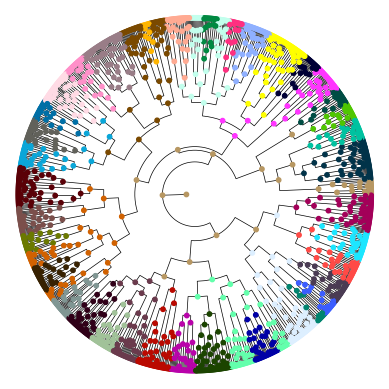

In [5]:
py.pl.tree(brownian_tdata, polar=True, node_color="leiden", nodes="all");

## Trajectory simulation

In [ ]:
basic_trajectory = cas.sim.complete_binary(8, alignment="nodes")
basic_trajectory = cas.sim.brownian_expression(basic_trajectory, momentum=0.95)
trajectory_data = cas.sim.trajectory_expression(
    tdata, basic_trajectory, random_seed=42, latent_noise=0.2
)

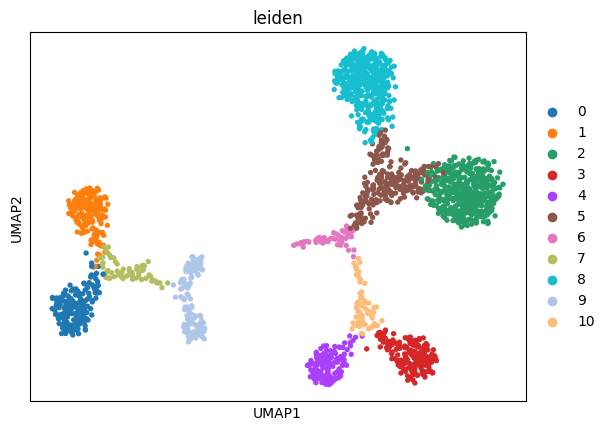

In [29]:
sc.pp.pca(trajectory_data)
sc.pp.neighbors(trajectory_data)
sc.tl.umap(trajectory_data)
sc.tl.leiden(trajectory_data, flavor="igraph")
sc.pl.umap(trajectory_data, color="leiden")

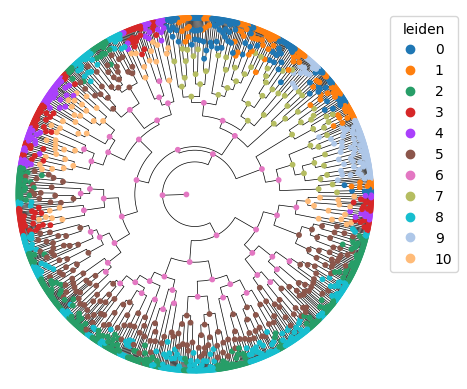

In [30]:
py.pl.tree(trajectory_data, polar=True, node_color="leiden", nodes="all");

# Manually specified trajectory

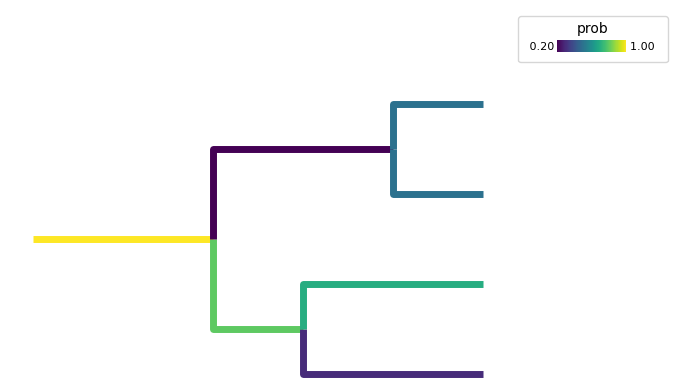

In [ ]:
custom_trajectory = nx.DiGraph()
custom_trajectory.add_edges_from(
    [("root", "0"), ("0", "1"), ("0", "2"), ("1", "3"), ("1", "4"), ("2", "5"), ("2", "6")]
)
nx.set_node_attributes(
    custom_trajectory,
    {"root": 0, "0": 0.4, "1": 0.6, "2": 0.8, "3": 1, "4": 1, "5": 1, "6": 1},
    "time",
)
nx.set_edge_attributes(
    custom_trajectory,
    {
        ("root", "0"): 1,
        ("0", "1"): 0.8,
        ("0", "2"): 0.2,
        ("1", "3"): 0.3,
        ("1", "4"): 0.7,
        ("2", "5"): 0.5,
        ("2", "6"): 0.5,
    },
    "prob",
)
custom_trajectory = td.TreeData(obst={"tree": custom_trajectory}, alignment="nodes")
custom_trajectory = cas.sim.brownian_expression(custom_trajectory, momentum=0.95)
py.pl.tree(custom_trajectory, branch_color="prob", depth_key="time", branch_linewidth=5);

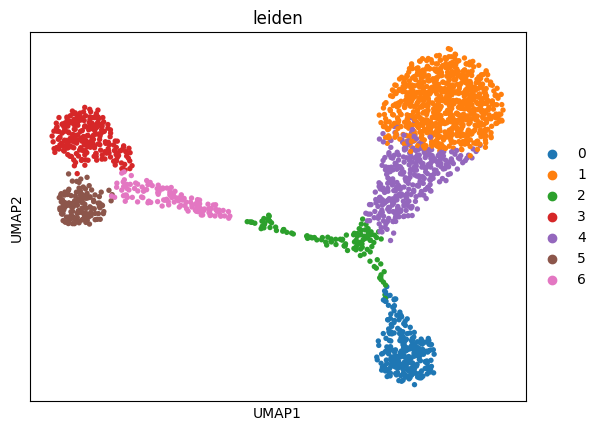

In [13]:
trajectory_data = cas.sim.trajectory_expression(
    tdata, custom_trajectory, random_seed=42, latent_noise=0.2, prob_key="prob"
)
sc.pp.pca(trajectory_data)
sc.pp.neighbors(trajectory_data)
sc.tl.umap(trajectory_data)
sc.tl.leiden(trajectory_data, flavor="igraph")
sc.pl.umap(trajectory_data, color="leiden")

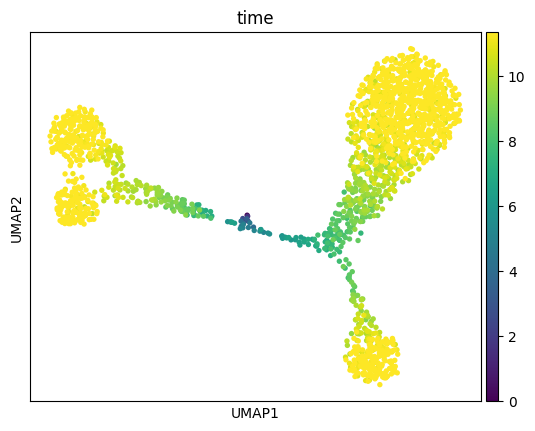

In [14]:
sc.pl.umap(trajectory_data, color="time")